# L01 Optional Extensions — go deeper (self-study)

> *Sarah Chen · Customer Experience Analyst · NorthStar Retail · January 2023.*
> This notebook is **optional**. It is not taught in class and is not assessed. Open it only if you want to look under the hood at things the core notebooks skipped.

## What this notebook covers and why it's optional

The L01 core class teaches three things: the mental model of ML, regression vs classification, and running a pre-trained model end-to-end. Those are the skills you'll use every day.

This notebook covers four related topics that were **demoted to self-study** because they are either (a) covered well by libraries in practice or (b) less frequently used across industries than the core topics:

1. **Polynomial features** — a classical way to let a linear model fit curved patterns. Rarely the first choice in production, but a clean illustration of *why* the right features matter.
2. **K-Nearest Neighbours (KNN) deep-dive** — a simple algorithm useful for intuition. Used in recommendation and similarity search, but usually beaten by tree-based models on tabular data.
3. **A mini neural network from scratch** — five lines of NumPy to show how a perceptron learns. Every library hides this, but seeing it once demystifies everything in L07.
4. **Train / test split theory** — *why* we split, *what* data leakage looks like, and why your model's score on training data can lie to you.

Work through them in order, or pick whichever interests you. Each section stands alone.

**Estimated time:** 45–60 minutes for all four. Each section is ~10–15 minutes.

## Setup

Run this cell first. It imports everything the rest of the notebook needs.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn will print some internal deprecation notes on newer Pythons.
# These are not errors; we silence them so the output stays clean for learning.
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_regression
from sklearn.metrics import accuracy_score, mean_squared_error

np.random.seed(42)
print("✅ Ready!")

---

## Section 1 — Polynomial features (when straight lines aren't enough)

**Scenario.** Priya pulls Sarah aside with a second question: *"Our product-page conversion rate isn't linear with price. Cheap things sell well, expensive things sell in small numbers, but there's a sweet spot in the middle. Linear regression keeps missing that shape. Can we do better without jumping to a complex model?"*

### The plain-English idea

Linear regression fits a straight line. If the real relationship is curved, a straight line will always miss.

**Polynomial features** solve this with a trick: we keep the linear model, but we *invent new features* that are the squares and cubes of the original one. The model is still linear in the parameters, but it can now fit curves.

**Analogy:** imagine you can only draw with a straight ruler. If you want a curve, you can't change the ruler — but you can put a bent piece of paper under it. The ruler is still straight; the paper makes the line look curved.

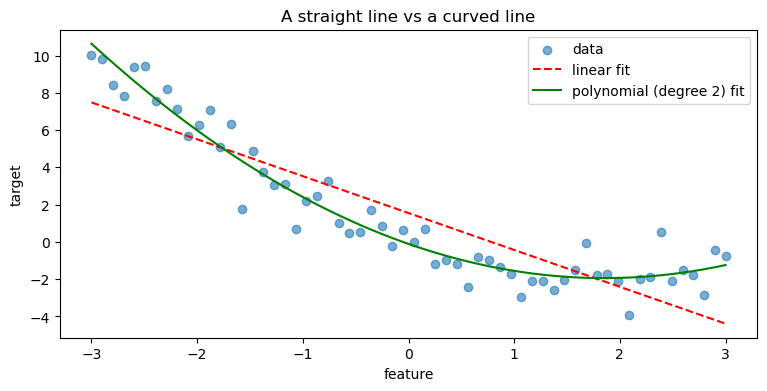

Linear RMSE:     1.75
Polynomial RMSE: 0.93


In [3]:
# Create a toy dataset that is clearly curved
X = np.linspace(-3, 3, 60).reshape(-1, 1)
y = 0.5 * X.ravel() ** 2 - 2 * X.ravel() + np.random.normal(0, 1, size=60)

# Fit a plain linear regression
lin = LinearRegression().fit(X, y)
y_pred_lin = lin.predict(X)

# Fit a polynomial regression (degree 2 = straight + x²)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression().fit(X_poly, y)
y_pred_poly = poly_model.predict(X_poly)

# Plot both
plt.figure(figsize=(9, 4))
plt.scatter(X, y, alpha=0.6, label='data')
plt.plot(X, y_pred_lin, 'r--', label='linear fit')
plt.plot(X, y_pred_poly, 'g-', label='polynomial (degree 2) fit')
plt.xlabel('feature'); plt.ylabel('target')
plt.title('A straight line vs a curved line')
plt.legend(); plt.show()

print(f'Linear RMSE:     {np.sqrt(mean_squared_error(y, y_pred_lin)):.2f}')
print(f'Polynomial RMSE: {np.sqrt(mean_squared_error(y, y_pred_poly)):.2f}')

### What do you notice?

- The green (polynomial) line follows the shape of the data; the red (linear) line flat-averages through it.
- The RMSE of the polynomial fit is noticeably lower — it's a better model *for this shape*.
- We didn't change the algorithm. We changed the *features*. That's the lesson.

### Why it's optional

In practice, you rarely hand-craft polynomial features any more. Tree-based models (L04) handle non-linearity automatically without you thinking about it. But seeing this makes a point that matters for every real project: **the right features often matter more than the right algorithm.**

---

## Section 2 — KNN deep-dive (learning by similarity)

**Scenario.** NorthStar's recommendation team wants a *quick* way to show "customers who bought this also bought..." suggestions. Before committing to a production system, they want a cheap baseline. Sarah reaches for KNN.

### The plain-English idea

K-Nearest Neighbours does no "training" in the usual sense. When you ask it to predict for a new point, it finds the **K most similar points** in the training data, and returns the majority answer.

**Analogy:** you want to know if a restaurant is good. You check the 5 nearest people who've been there recently (the K=5 neighbours). If 4 out of 5 say yes, you go.

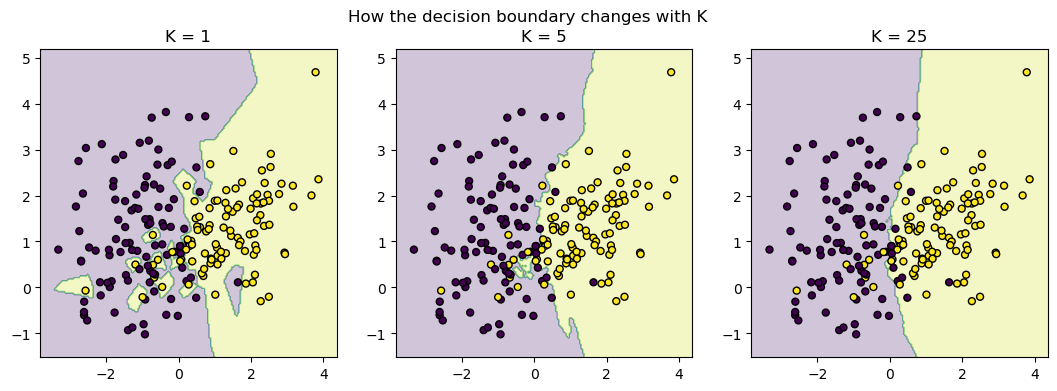

In [4]:
# Create a 2-feature classification dataset so we can visualise it
X2, y2 = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.2, random_state=42,
)

# Try three values of K and compare
ks = [1, 5, 25]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min()-0.5, X2[:, 0].max()+0.5, 200),
    np.linspace(X2[:, 1].min()-0.5, X2[:, 1].max()+0.5, 200),
)

for ax, k in zip(axes, ks):
    model = KNeighborsClassifier(n_neighbors=k).fit(X2, y2)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X2[:, 0], X2[:, 1], c=y2, edgecolor='k', s=25)
    ax.set_title(f'K = {k}')
plt.suptitle('How the decision boundary changes with K'); plt.show()

### What do you notice?

- **K=1** is very wiggly — every single point has its own tiny region. It memorises the training data (this is called *overfitting*).
- **K=5** is smoother — a reasonable compromise.
- **K=25** is very smooth — but look at the edges; it blurs across the real boundary between the two classes (this is called *underfitting*).

The choice of K is the single hyperparameter you tune. Too small = overfits; too large = underfits.

### Why it's optional

KNN is simple and good for intuition. In production, two limitations hurt it: (1) every prediction requires looking at all training data, which is slow at scale; (2) it is very sensitive to feature scaling — if one feature has much larger values than another, it dominates the distance calculation. Tree-based models (L04) don't have either problem. That's why KNN gets one mention in the core and a deeper look here.

---

## Section 3 — A mini neural network from scratch (five lines of NumPy)

**Scenario.** Sarah is curious. Every library she's used — TextBlob, scikit-learn — calls itself "AI" and hides what's really happening. She opens a blank notebook and asks: *"What is the simplest possible thing that could learn from data?"*

### The plain-English idea

A **perceptron** — the simplest neural network — is a weighted sum followed by a decision.

For every input row, it:
1. Multiplies each feature by its *weight*, adds them up, adds a *bias*, and passes the result through an activation function (here, a step function: 0 or 1).
2. Compares its prediction to the true label.
3. If wrong, nudges the weights in the direction that would have made it less wrong.

That third step is **learning**. It really is that simple. Run the cell below.

In [ ]:
# Toy data: the AND function
#  x1  x2 | target
#   0   0 |   0
#   0   1 |   0
#   1   0 |   0
#   1   1 |   1
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

w = np.zeros(2)   # two weights, one per feature — start at zero
b = 0.0           # bias
lr = 0.1          # learning rate — how big each nudge is

for epoch in range(20):
    for xi, target in zip(X, y):
        prediction = 1 if np.dot(xi, w) + b > 0 else 0
        error = target - prediction         # +1, 0, or -1
        w = w + lr * error * xi              # nudge the weights
        b = b + lr * error                   # nudge the bias

print(f'Learned weights: {w}')
print(f'Learned bias:    {b:.2f}')
print('\nPredictions after training:')
for xi, target in zip(X, y):
    pred = 1 if np.dot(xi, w) + b > 0 else 0
    print(f'  x = {xi}  target = {target}  predicted = {pred}')

Learned weights: [1.2 0.6]
Learned bias:    -1.20

Predictions after training:
  x = [0 0]  target = 0  predicted = 0
  x = [0 1]  target = 0  predicted = 0
  x = [1 0]  target = 0  predicted = 0
  x = [1 1]  target = 1  predicted = 1


### What do you notice?

- The perceptron started with zero weights and learned the AND function just by seeing examples.
- No library. No "AI." Just `np.dot`, a comparison, and a nudge.
- This is the **atomic unit** of every neural network in L07–L10. Modern networks stack millions of these together, and use smoother activation functions and cleverer learning algorithms, but the core idea is this.

### Why it's optional

You will never write this code in a real job — PyTorch does it for you. But seeing it once, in 15 lines, removes all the mystery. When L07 introduces gradient descent and backpropagation, you'll recognise it as a fancier version of the nudge-the-weights pattern you just saw.

---

## Section 4 — Train / test split theory (why your model's score can lie)

**Scenario.** A few weeks into her role, Sarah builds a sentiment classifier that scores **98% accuracy** on her data. She proudly walks it to Priya. Priya asks one question: *"98% on which data?"* Sarah realises she scored it on the same reviews she trained on.

### The plain-English idea

A model can **memorise** training data and look amazing on it — then fail completely on new data.

**Analogy:** if you give a student the exact exam questions in advance and let them memorise the answers, they'll score 100% on the exam. That score tells you nothing about whether they've learned the material.

The fix is the **train / test split**: hide some of the data during training. Score the model only on data it has never seen. That score is your honest answer to *"how good is this model?"*

Let's make this concrete.

In [6]:
# A simple regression problem
X, y = make_regression(n_samples=200, n_features=5, noise=10, random_state=2)

# Train / test split — hide 25% for honest scoring
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2)

model = LinearRegression().fit(X_train, y_train)

train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
test_rmse  = np.sqrt(mean_squared_error(y_test,  model.predict(X_test)))

print(f'RMSE on training data:        {train_rmse:6.2f}   ← always looks better')
print(f'RMSE on held-out test data:   {test_rmse:6.2f}   ← the honest score')

RMSE on training data:          8.36   ← always looks better
RMSE on held-out test data:    11.23   ← the honest score


### What do you notice?

- The **training RMSE** is lower — the model has seen this data.
- The **test RMSE** is slightly higher — this is the honest estimate of how the model will perform on future data.
- In a **well-fitting** model, the two numbers are close (as here). In a model that has overfit, the training score is great and the test score is terrible.

### A word about data leakage

The train/test split only works if you are disciplined. The single most common mistake is **data leakage** — accidentally letting information from the test set touch the training process.

Classic examples:

- Scaling features using the mean of the *whole* dataset (including test) before splitting. The test data has contaminated the training statistics.
- Doing feature selection with both train and test together.
- For time series: randomly shuffling before splitting, so the model sees *future* data while training.

L03 teaches the sklearn `Pipeline` — the standard tool for avoiding data leakage. That's why Pipeline is Core.

### Why it's optional

The *mechanics* of train/test split are covered in L03 (and the `train_test_split` call is one line). The **theory and the leakage traps** go deeper than a 3-hour class can support, which is why they live here.

---

## ✅ End of Optional Extensions

| Section | What you saw | Where it comes back |
|---|---|---|
| Polynomial features | Non-linear relationships can be fit by a linear model with better features | L03 (feature engineering) · L04 (trees handle this automatically) |
| KNN deep-dive | Learning by similarity; the K hyperparameter; overfit vs underfit visually | L03 (bias-variance tradeoff as a concept) |
| Mini neural network | The atomic unit of every neural network — a weighted sum + a nudge | L07 (gradient descent + backprop, at scale) |
| Train/test split theory | Why held-out scores are the only honest scores + what data leakage looks like | L03 (k-fold cross-validation) · L04 (Pipeline to prevent leakage) |

**You do not need to do anything with this notebook.** There is no assignment and no self-check. If any of the four topics sparked follow-up questions, bring them to class — the instructor will be glad to go deeper.

**Next step →** return to the [L01 README](../README.md) if you came here from there, or go straight to [`assignment.ipynb`](./assignment.ipynb) for the Lakeside Bank application.